# Count map from $m_5$

In [1]:
import numpy as np
import dask.array as da
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.table import Table
import healpy as hp
import matplotlib.pyplot as plt

from simulMap import *
from fitMap import *
from lumMag_sampling import *
from mappers import DepthMapper, CountMapper
import pyccl as ccl

# Set random seed for reproducibility
#np.random.seed(42)

In [2]:
#resolution:
nside = 64
npix = hp.nside2npix(nside)
print("Number of pixels = {}".format(npix))

Number of pixels = 49152


## $m_5$ magnitude

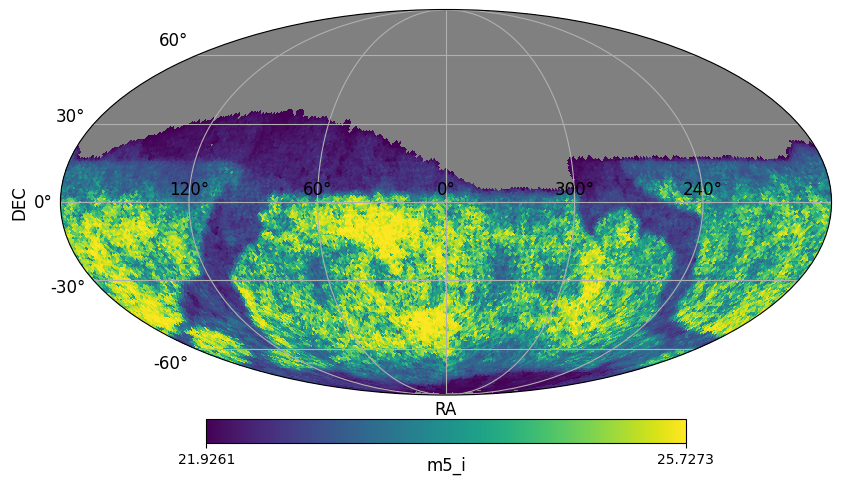

In [3]:
DIR = '../data/'
FILE = DIR + "baseline_v5.0.0_10yrs_summary.hdf5"
dm = DepthMapper.read_hdf(FILE)
dm.select_year(1)
band = 'i'
dm.select_band(band)
dm.set_mask()
dm.plot()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 316.7 (χ²/ndof = 0.0)      │              Nfcn = 741              │
│ EDM = 2.13e-05 (Goal: 0.0002)    │            time = 9.2 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │  24.805   │   0.035   │   -0.035   │   0.035    │    0    │         │       │
│ 1 │ A    │  0.0222   │  0.0027   │  -0.0027   │   0.0027   │    0    │    1    │       │
│ 2 │ ra   │    259    │    25     │    -26     │     25     │    0    │   360   │       │
│ 3 │ dec  │    -79    │     5     │     -5     │     5      │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │  -0.035   │   0.035   │  -0.0027  │  0.0027   │    -26    │    26     │    -5     │     5     │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────┐
│     │        N*         A        ra       dec │
├─────┼─────────────────────────────────────────┤
│  N* │   0.00124    -59e-6    0.0844    0.0559 │
│   A │    -59e-6   7.3e-06 -5.470e-3 -3.961e-3 │
│  ra │    0.0844 -5.470e-3       625         5 │
│ dec │    0.0559 -3.961e-3         5      24.8 │
└─────┴─────────────────────────────────────────┘

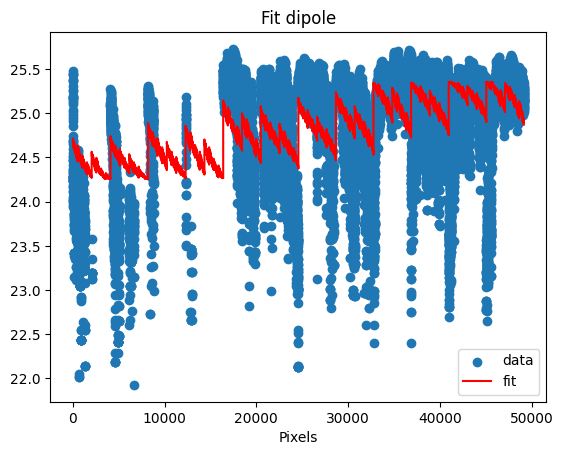

In [4]:
init =  (10, 1, 100, 40)
m = dm.fit_dipole("iMasked", init, plot_map=False)
m

## Ratio determination

In [5]:
NSource_px_th = int(1e6)
dataN = generate_lumMag(NSource_px_th, to_table=True)
dataN


Generating redshifts
Number of rejects = 689455
Accepted ratio = 77%

Generating dL
Generating luminosities
Number of rejects = 685752
Accepted ratio = 77%


z,dL,L,M,m
,Mpc,solLum,,
float64,float64,float64,float64,float64
0.4193388455694577,2376.6113266470697,479909618.2902282,-16.872898635242137,25.006892177701584
0.3244493599096014,1760.6978672407542,853114353.2409421,-17.497518122036375,23.7309060687949
0.5326764030973358,3159.8500336185116,688883014.9643115,-17.265363692399276,25.232968665127157
0.1273664622272502,619.4929221124737,213426644.41076887,-15.993121590652711,22.967060153343084
0.7870748195646142,5073.7448544351855,11210867.928830082,-12.79409809083406,30.732545028583694
1.2809306958497655,9233.722926509128,19051111991.40965,-20.869800825047307,23.957083368299518
0.9067296252212083,6035.16366431154,2051619996.9512959,-18.450242308606732,25.45320295133443
0.9780308634381268,6623.714581117507,31291526.744880185,-13.90856688331298,30.19694116785049


Saving LumDist in Simul_Figures/Simul_Schechter/Schechter_LumDist.pdf


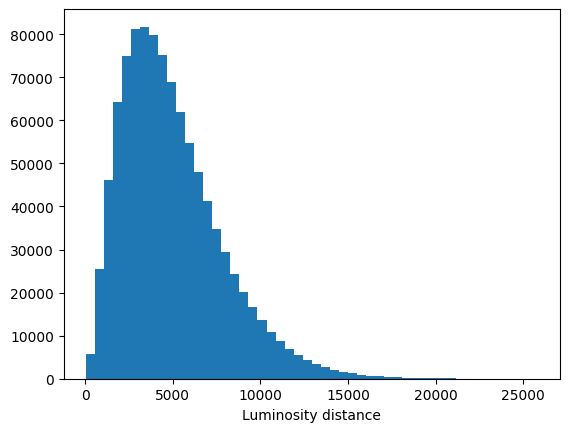

In [6]:
get_hist(dataN["dL"], xlabel='Luminosity distance', bins=50);

output_path = "Simul_Figures/Simul_Schechter/Schechter_"
get_savefig(plt, output_path, "LumDist")

Saving LumDistLogLog in Simul_Figures/Simul_Schechter/Schechter_LumDistLogLog.pdf


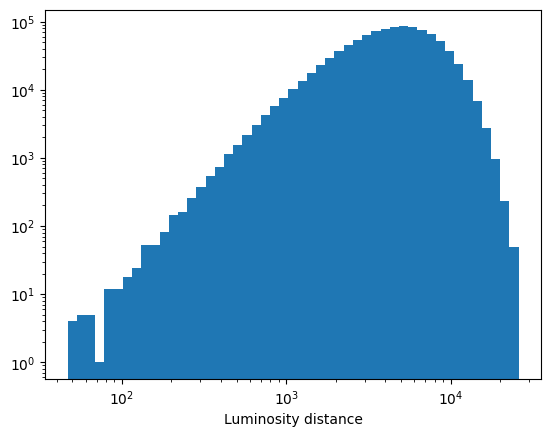

In [7]:
binsdL = np.logspace(np.log10(np.min(dataN["dL"])), np.log10(np.max(dataN["dL"])), 50)
get_hist(dataN["dL"], xlabel='Luminosity distance', bins=binsdL, log=True);
plt.xscale('log')

output_path = "Simul_Figures/Simul_Schechter/Schechter_"
get_savefig(plt, output_path, "LumDistLogLog")

Saving ApparentMag in Simul_Figures/Simul_Schechter/Schechter_ApparentMag.pdf


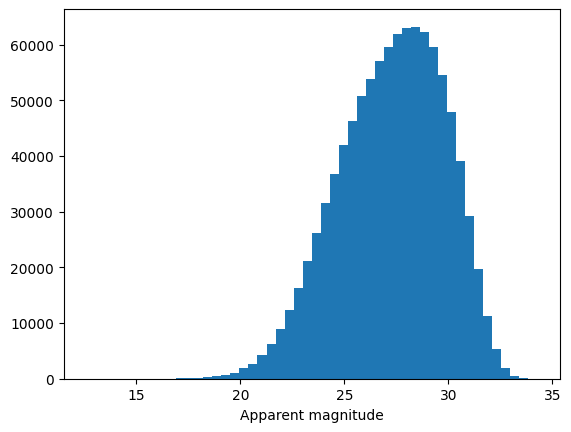

In [8]:
get_hist(dataN["m"], xlabel='Apparent magnitude', bins=50, label="$m$")

output_path = "Simul_Figures/Simul_Schechter/Schechter_"
get_savefig(plt, output_path, "ApparentMag")

Saving ApparentMag_cut in Simul_Figures/Simul_Schechter/Schechter_ApparentMag_cut.pdf


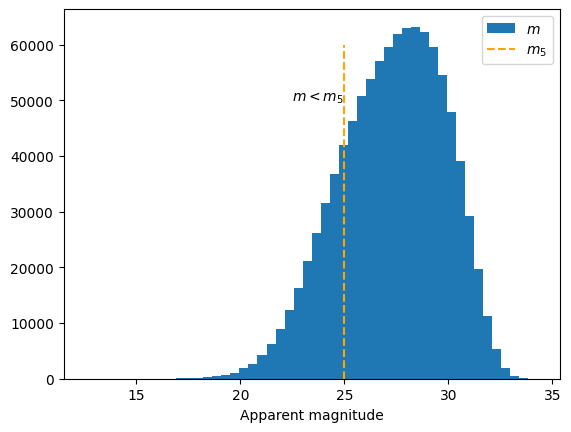

In [9]:
get_hist(dataN["m"], xlabel='Apparent magnitude', bins=50, label="$m$");
plt.vlines(25, 0, 60000, linestyles = 'dashed', colors="orange", label="$m_5$")
plt.text(22.5, 50000, "$m < m_5$")
plt.legend()

output_path = "Simul_Figures/Simul_Schechter/Schechter_"
get_savefig(plt, output_path, "ApparentMag_cut")

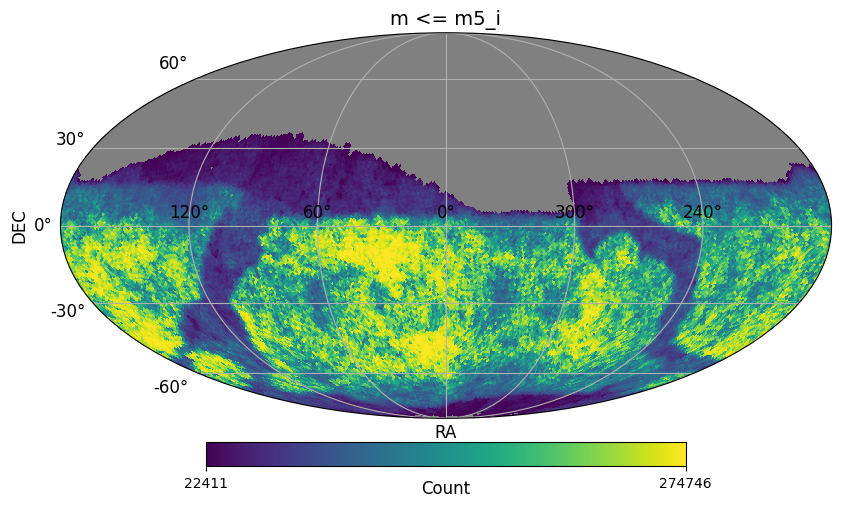

In [10]:
NSource_px = cut_m52map(dataN["m"], dm.m5i.copy())
countMapper = CountMapper.from_map(NSource_px)
countMapper.set_mask()
countMapper.plot("Masked", norm="hist", title= "m <= m5_i")

output_path = "Simul_Figures/Simul_Magnitude/"
#get_savefig(plt, output_path, "CountMap_m5band_i")

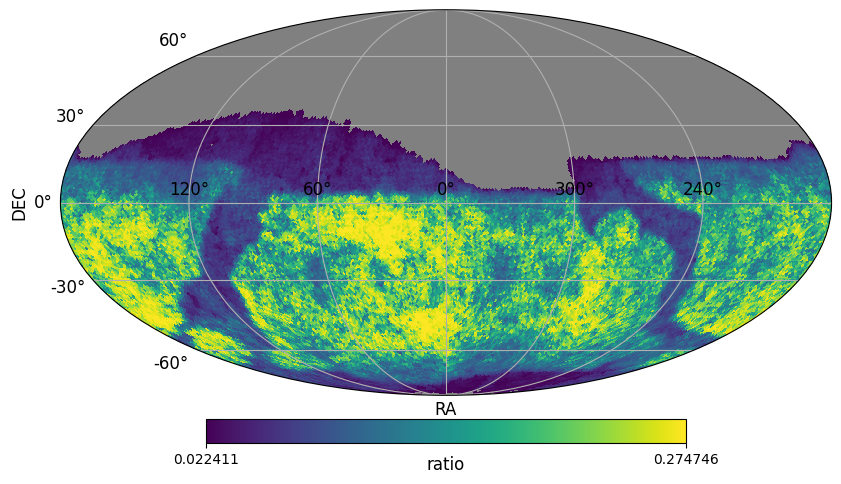

In [11]:
ratioMapper = CountMapper.from_map(countMapper.map/NSource_px_th)
ratioMapper._set_instance_settingsPlot(unit = 'ratio')
ratioMapper.set_mask()
ratioMapper.plot("Masked", norm="hist")

output_path = "Simul_Figures/Simul_Magnitude/"
#get_savefig(plt, output_path, "RatioMap_m5band_i")

## Souce sampling

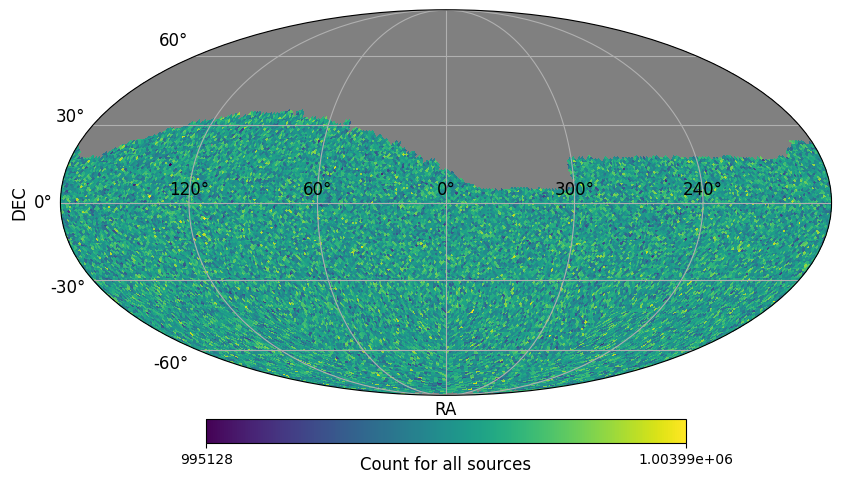

In [12]:
count_thMapper = CountMapper.from_map(np.random.poisson(NSource_px_th, npix))
count_thMapper._set_suffixTextPlot(unit = "all sources")
count_thMapper.set_mask(dm.m5iMasked.mask)
count_thMapper.plot("Masked")

output_path = "Simul_Figures/Simul_Magnitude/"
#get_savefig(plt, output_path, "All_m_Map")

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3.325e+04 (χ²/ndof = 0.7)  │              Nfcn = 617              │
│ EDM = 2.9e-05 (Goal: 0.0002)     │            time = 5.8 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │ 999.990e3 │  0.007e3  │  -0.007e3  │  0.007e3   │    0    │         │       │
│ 1 │ A    │ 0.011e-3  │ 0.014e-3  │ -0.011e-3  │  0.014e-3  │    0    │    1    │       │
│ 2 │ ra   │  0.12e3   │  0.10e3   │  -0.12e3   │   0.24e3   │    0    │   360   │       │
│ 3 │ dec  │    -65    │    43     │    -25     │    155     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │    -7     │     7     │ -0.011e-3 │ 0.014e-3  │  -0.12e3  │  0.24e3   │    -25    │    155    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   True    │   False   │   True    │   True    │   True    │   True    │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────────────┐
│     │            N*             A            ra           dec │
├─────┼─────────────────────────────────────────────────────────┤
│  N* │          50.4  -60.91062e-6            30            80 │
│   A │  -60.91062e-6      1.88e-10  -41.90426e-6 -135.15141e-6 │
│  ra │            30  -41.90426e-6      1.19e+04         0.3e3 │
│ dec │            80 -135.15141e-6         0.3e3      2.25e+03 │
└─────┴─────────────────────────────────────────────────────────┘

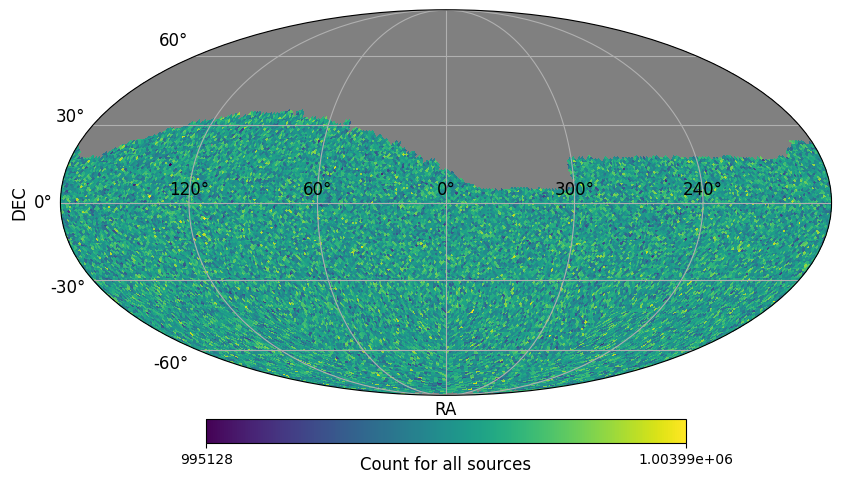

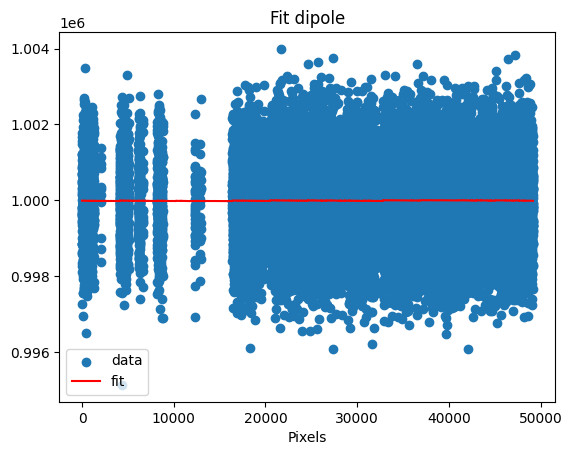

In [13]:
init =  (1e6, 0, 100, 40)
count_thMapper.fit_dipole("Masked", init)

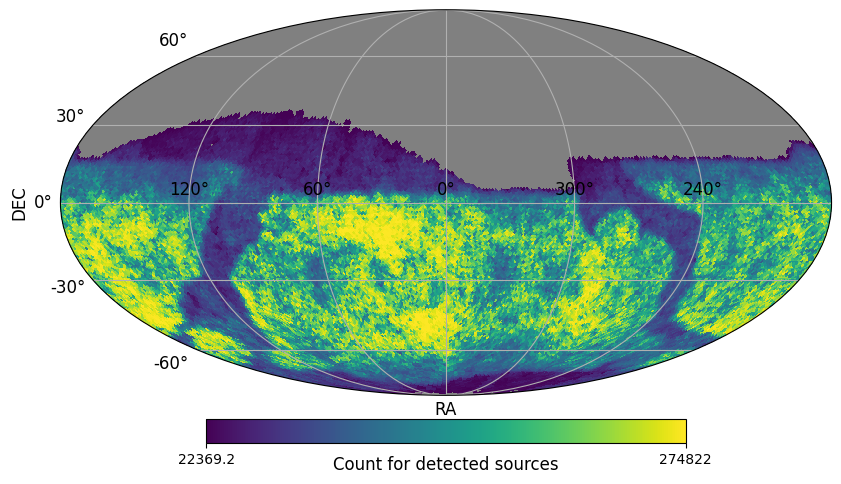

In [14]:
countDetectedMapper = CountMapper.from_map(count_thMapper.map * ratioMapper.map)
countDetectedMapper._set_suffixTextPlot(unit = "detected sources")
countDetectedMapper.set_mask()
countDetectedMapper.plot("Masked", norm="hist")

output_path = "Simul_Figures/Simul_Magnitude/"
#get_savefig(plt, output_path, "DetectMap_m5band_i")

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 4.536e+08 (χ²/ndof = 9229.8)│              Nfcn = 364              │
│ EDM = 2.66e-05 (Goal: 0.0002)    │            time = 3.9 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │168.6386e3 │ 0.0028e3  │ -0.0028e3  │  0.0028e3  │    0    │         │       │
│ 1 │ A    │328.889e-3 │ 0.033e-3  │ -0.033e-3  │  0.033e-3  │    0    │    1    │       │
│ 2 │ ra   │  255.279  │   0.020   │   -0.020   │   0.020    │    0    │   360   │       │
│ 3 │ dec  │  -77.712  │   0.004   │   -0.004   │   0.004    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -2.8    │    2.8    │ -0.033e-3 │ 0.033e-3  │   -0.02   │   0.02    │  -0.004   │   0.004   │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────┐
│     │          N*           A          ra         dec │
├─────┼─────────────────────────────────────────────────┤
│  N* │        7.69 -56.5987e-6      5.4e-3    4.230e-3 │
│   A │ -56.5987e-6    1.11e-09    -57.8e-9    -51.6e-9 │
│  ra │      5.4e-3    -57.8e-9     0.00039    0.001e-3 │
│ dec │    4.230e-3    -51.6e-9    0.001e-3    1.84e-05 │
└─────┴─────────────────────────────────────────────────┘

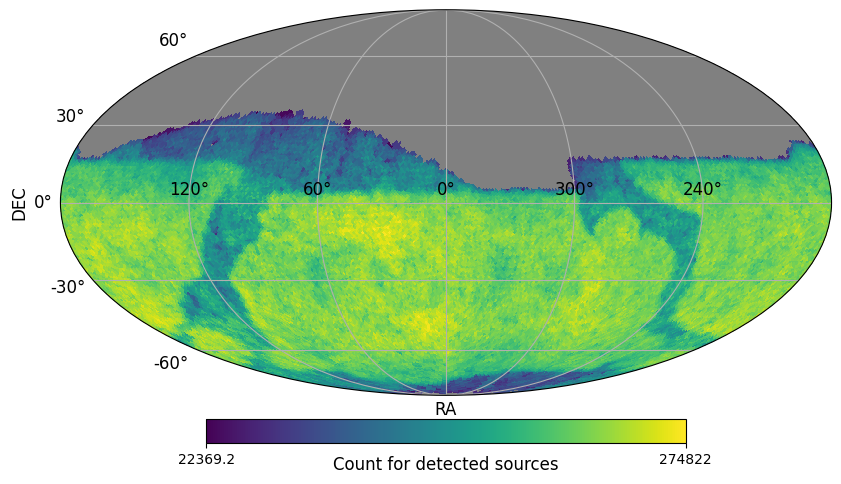

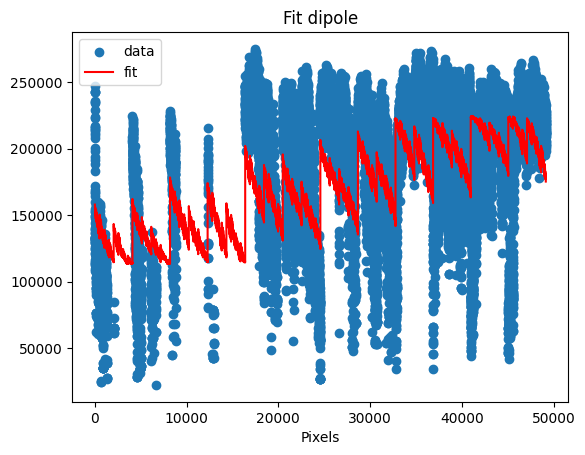

In [15]:
init =  (1e5, 1, 100, 40)
countDetectedMapper.fit_dipole("Masked", init)

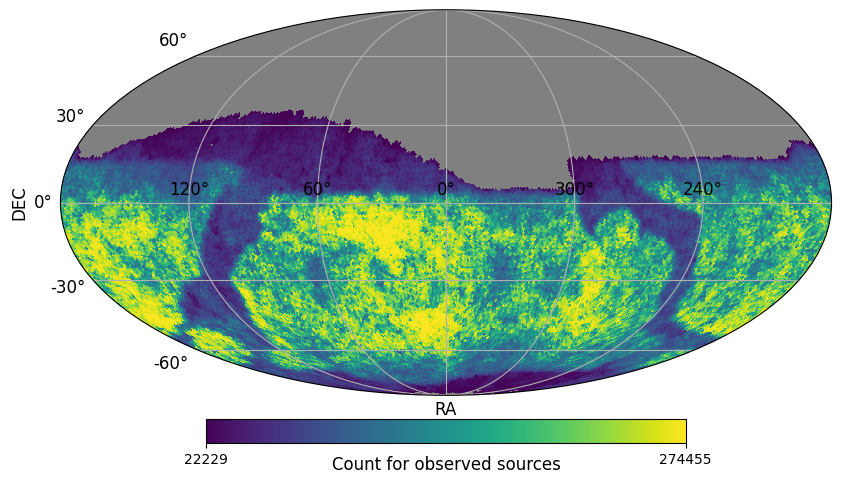

In [16]:
countObservedMapper = CountMapper.from_map(np.random.poisson(countDetectedMapper.map))
countObservedMapper._set_suffixTextPlot(unit = "observed sources")
countObservedMapper.set_mask(dm.m5iMasked.mask)
countObservedMapper.plot("Masked", norm='hist')

output_path = "Simul_Figures/Simul_Magnitude/"
#get_savefig(plt, output_path, "ObservMap_m5band_i_poissOnly")

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 4.536e+08 (χ²/ndof = 9229.9)│              Nfcn = 387              │
│ EDM = 2.66e-05 (Goal: 0.0002)    │            time = 3.8 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │168.6368e3 │ 0.0028e3  │ -0.0028e3  │  0.0028e3  │    0    │         │       │
│ 1 │ A    │328.861e-3 │ 0.033e-3  │ -0.033e-3  │  0.033e-3  │    0    │    1    │       │
│ 2 │ ra   │  255.256  │   0.020   │   -0.020   │   0.020    │    0    │   360   │       │
│ 3 │ dec  │  -77.714  │   0.004   │   -0.004   │   0.004    │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -2.8    │    2.8    │ -0.033e-3 │ 0.033e-3  │   -0.02   │   0.02    │  -0.004   │   0.004   │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────┐
│     │          N*           A          ra         dec │
├─────┼─────────────────────────────────────────────────┤
│  N* │        7.69 -56.5999e-6      5.4e-3    4.229e-3 │
│   A │ -56.5999e-6    1.11e-09    -57.9e-9    -51.6e-9 │
│  ra │      5.4e-3    -57.9e-9    0.000391    0.001e-3 │
│ dec │    4.229e-3    -51.6e-9    0.001e-3    1.84e-05 │
└─────┴─────────────────────────────────────────────────┘

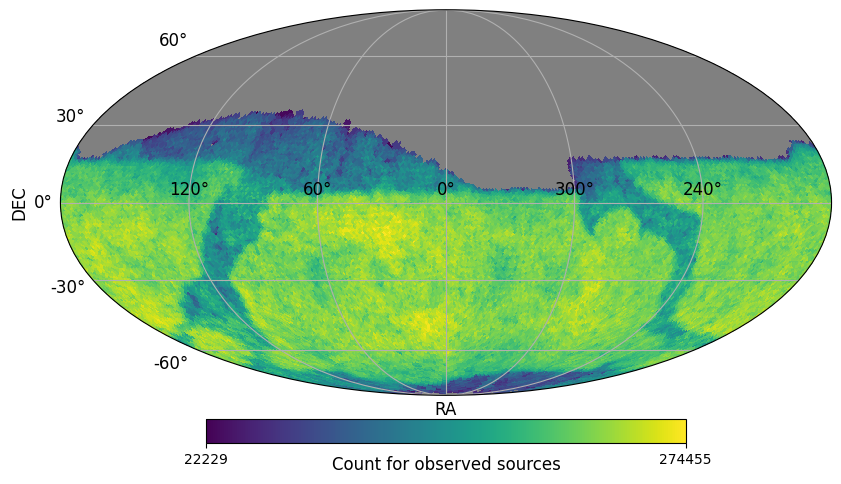

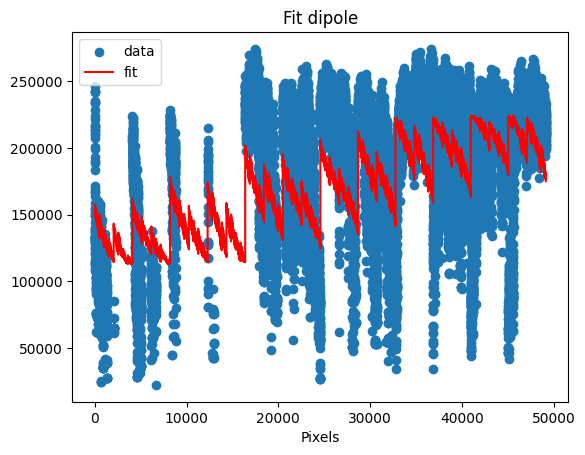

In [17]:
init =  (1e5, 1, 100, 40)
countObservedMapper.fit_dipole("Masked", init)

/tmp/ipykernel_1445/216236427.py:1: RuntimeWarning: invalid value encountered in divide
  countCorrectedMapper = CountMapper.from_map(countObservedMapper.map / ratioMapper.map)


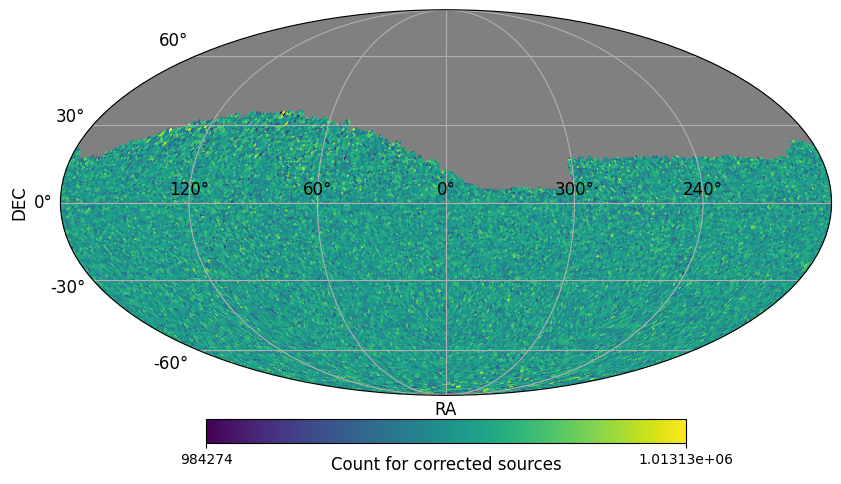

In [18]:
countCorrectedMapper = CountMapper.from_map(countObservedMapper.map / ratioMapper.map)
countCorrectedMapper.fillna()
countCorrectedMapper._set_suffixTextPlot(unit = "corrected sources")
countCorrectedMapper.set_mask()
countCorrectedMapper.plot("Masked")

output_path = "Simul_Figures/Simul_Magnitude/"
#get_savefig(plt, output_path, "CorrectMap_m5band_i_poissOnly")

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.155e+05 (χ²/ndof = 4.4)  │              Nfcn = 474              │
│ EDM = 8.41e-05 (Goal: 0.0002)    │            time = 4.8 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ N*   │ 999.973e3 │  0.007e3  │  -0.007e3  │  0.007e3   │    0    │         │       │
│ 1 │ A    │ 0.024e-3  │ 0.011e-3  │ -0.010e-3  │  0.011e-3  │    0    │    1    │       │
│ 2 │ ra   │    137    │    23     │    -24     │     24     │    0    │   360   │       │
│ 3 │ dec  │    -21    │    31     │    -27     │     36     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │          N*           │           A           │          ra           │          dec          │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │    -7     │     7     │ -0.010e-3 │ 0.011e-3  │    -24    │    24     │    -27    │    36     │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────────────────────────────────────────────┐
│     │            N*             A            ra           dec │
├─────┼─────────────────────────────────────────────────────────┤
│  N* │          50.9  -32.78306e-6            10           130 │
│   A │  -32.78306e-6      1.13e-10   -5.86647e-6 -122.27719e-6 │
│  ra │            10   -5.86647e-6           536         0.1e3 │
│ dec │           130 -122.27719e-6         0.1e3           972 │
└─────┴─────────────────────────────────────────────────────────┘

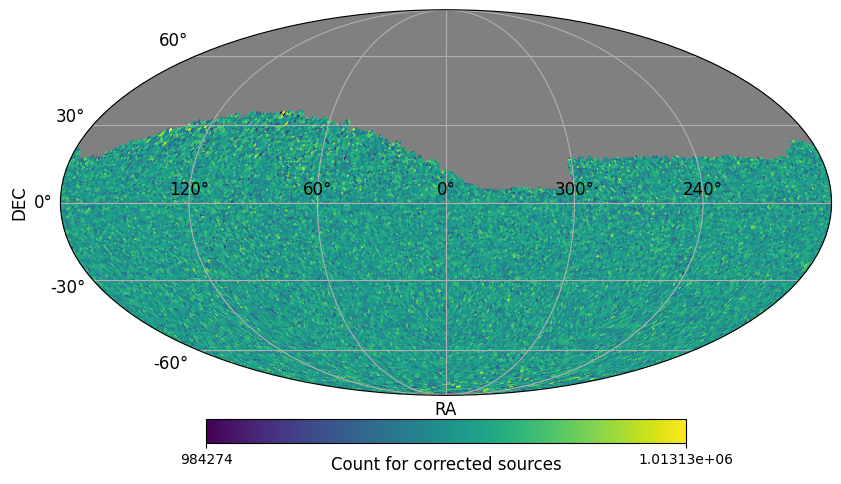

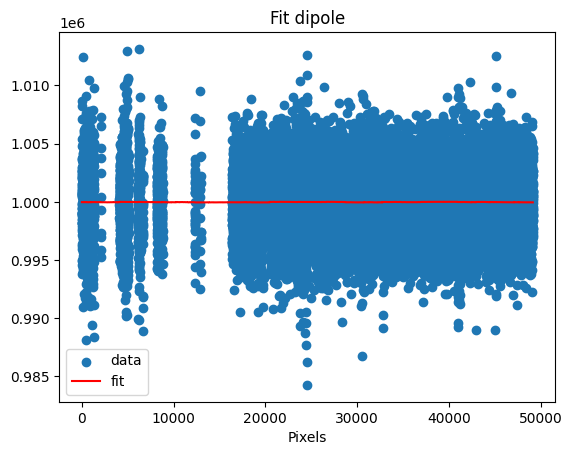

In [19]:
init =  (1e6, 0, 100, 40)
countCorrectedMapper.fit_dipole("Masked", init)

## Smoothing the map

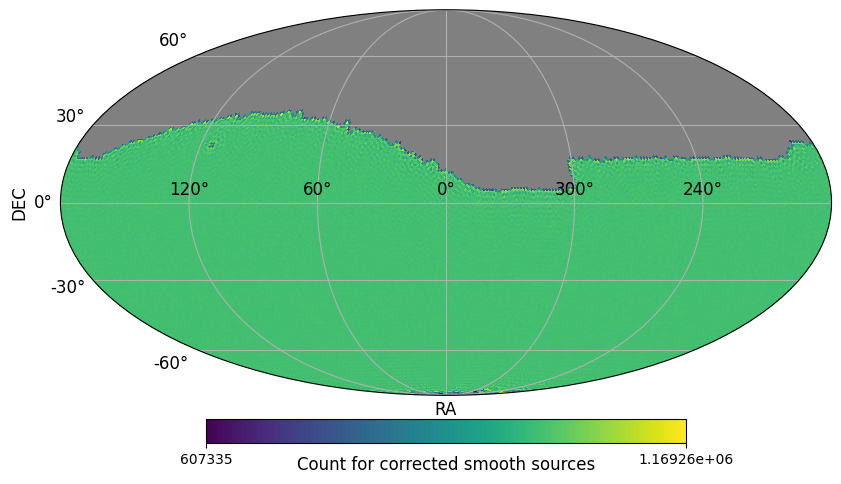

In [42]:
countSmoothMapper = CountMapper.from_map(hp.smoothing(countCorrectedMapper.map, nest=True, sigma=0.005))
countSmoothMapper._set_suffixTextPlot(unit = "corrected smooth sources")
countSmoothMapper.set_mask(countCorrectedMapper.mapMasked.mask)
countSmoothMapper.plot("Masked")

output_path = "Simul_Figures/Simul_Magnitude/"
#get_savefig(plt, output_path, "SmoothMap_m5band_i_poissOnly")

In [20]:
hp.smoothing

Signature:
hp.smoothing(
    map_in,
    fwhm=0.0,
    sigma=None,
    beam_window=None,
    pol=True,
    iter=3,
    lmax=None,
    mmax=None,
    use_weights=False,
    use_pixel_weights=False,
    datapath=None,
    verbose=True,
    nest=False,
)
Docstring:
Smooth a map with a Gaussian symmetric beam.

No removal of monopole or dipole is performed.

Parameters
----------
map_in : array or sequence of 3 arrays
  Either an array representing one map, or a sequence of
  3 arrays representing 3 maps, accepts masked arrays
fwhm : float, optional
  The full width half max parameter of the Gaussian [in
  radians]. Default:0.0
sigma : float, optional
  The sigma of the Gaussian [in radians]. Override fwhm.
beam_window: array, optional
  Custom beam window function. Override fwhm and sigma.
pol : bool, optional
  If True, assumes input maps are TQU. Output will be TQU maps.
  (input must be 1 or 3 alms)
  If False, each map is assumed to be a spin 0 map and is
  treated independently (inpu